<a href="https://colab.research.google.com/github/Pruthvi618/customer-churn-prediction/blob/main/customer_churn_prediction_using_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Customer Churn Prediction using Logistic Regression

## 🎯 Objective
The goal of this project is to predict whether a customer will churn (leave the service) based on their demographic and service usage data.

## 💼 Business Problem
Customer churn leads to revenue loss. By predicting churn in advance, the company can take proactive actions such as targeted offers or customer engagement strategies to retain customers.

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📥 Data Loading and Initial Inspection

In [ ]:
# Loading Data
data = pd.read_csv('/content/drive/MyDrive/Data Science /Machine Learning Projects/Logistic Regression/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.DataFrame(data)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🔍 Data Understanding

- Checked dataset shape and structure  
- Identified data types and missing values  
- Observed that `TotalCharges` needed conversion  

In [ ]:
# Gives Information of null and non-null object
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isna().sum() # whether features have NaN value or not

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe() # Basic Statistics

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.shape # Shape of Data

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Number of categorical columns
catergorical_columns = df.select_dtypes(include = "object").columns.tolist()
len(catergorical_columns)

18

In [ ]:
# Number of Numerical Columns
numerical_columns = df.select_dtypes(include = "number").columns.tolist()
len(numerical_columns)

3

In [ ]:
numerical_columns

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [ ]:
df['SeniorCitizen'].unique()  # since SeniorCitizen has only two unique number that is 0 and 1 so we can consider it as categorical column

array([0, 1])

In [ ]:
# Add SeniorCitizen feature to categorical column
catergorical_columns += ['SeniorCitizen']

catergorical_columns

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn',
 'SeniorCitizen']

## 🧹 Data Cleaning

- Converted `TotalCharges` to numeric  
- Removed missing values  
- Dropped irrelevant column `customerID`  
- Simplified categorical values  

In [ ]:
# TotalCharges is in categorical column but it has to be numerical

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isna().sum())



float64
11


In [ ]:
# dropping NaN values
df.dropna(inplace = True)
print(df.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
# Check Unique values
for column in catergorical_columns:
  print(f'{column} : {df[column].unique()}')

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges : [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn : ['No' 'Yes']
SeniorCitizen : [0 1]


In [ ]:
replace_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines'
]

# Create a single dictionary for all replacements
replacement_map = {
    'No internet service': 'No',
    'No phone service': 'No'
}

for col in replace_cols:
  # Use the single replacement map for each column
  df[col] = df[col].replace(replacement_map)

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
# Drop customer ID which won't affect the model
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


## 📊 Exploratory Data Analysis



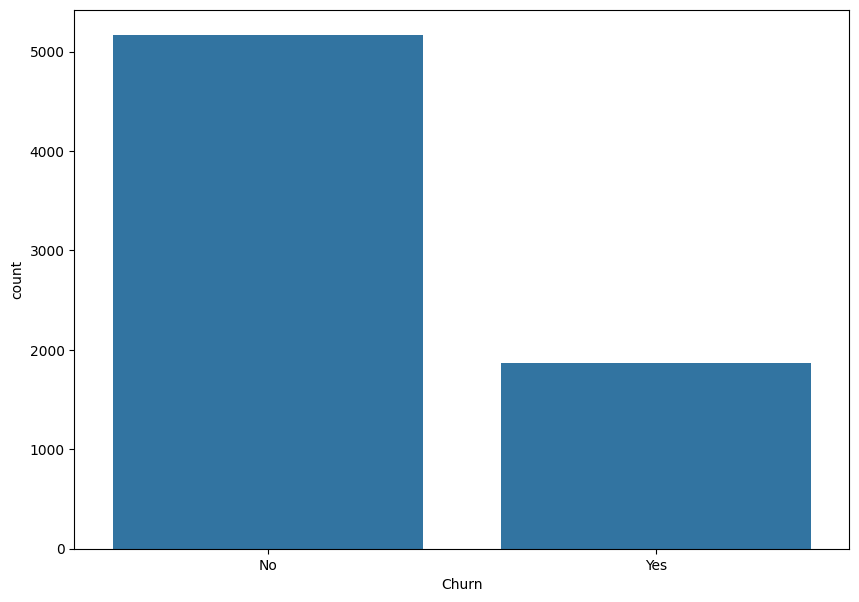

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (10, 7))
sns.countplot(data = df, x = 'Churn')
plt.show()

The countplot clearly shows that the dataset is imbalanced. There are significantly more customers who have 'No' churn than those who have 'Yes' churn. Specifically, the number of non-churning customers is much higher than the number of churning customers. This data imbalance is an important observation, as it can affect the performance of machine learning models if not addressed during training.

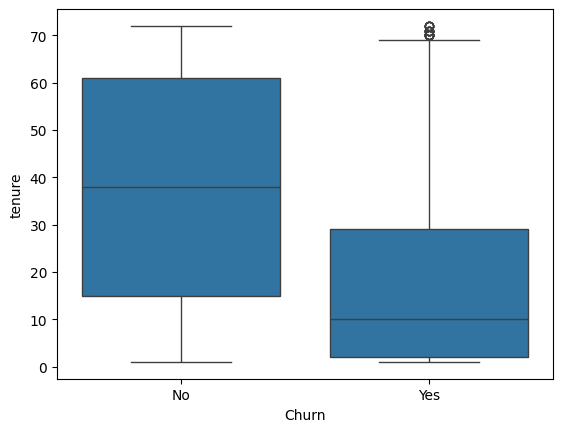

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

The boxplot illustrates the relationship between customer churn and their tenure. It appears that customers who churn ('Yes') generally have a lower tenure than those who do not churn ('No'). The median tenure for churned customers is noticeably lower, and their distribution is concentrated at shorter tenures compared to non-churned customers, whose tenure distribution extends much higher.

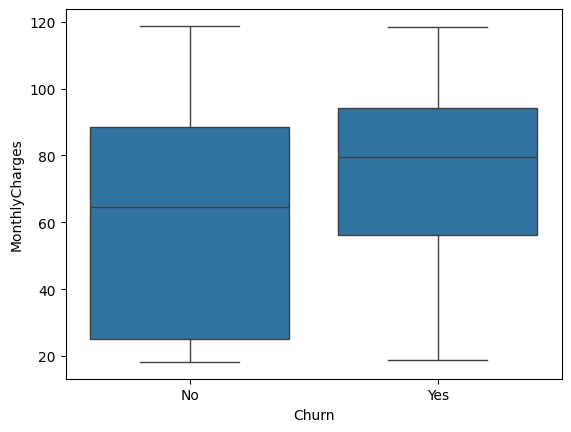

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

The boxplot comparing 'Churn' and 'MonthlyCharges' shows that customers who churn (labeled 'Yes') tend to have higher monthly charges than those who do not churn (labeled 'No'). The median monthly charge for churned customers is noticeably higher, and their distribution is shifted towards the upper end of monthly charges compared to non-churned customers.

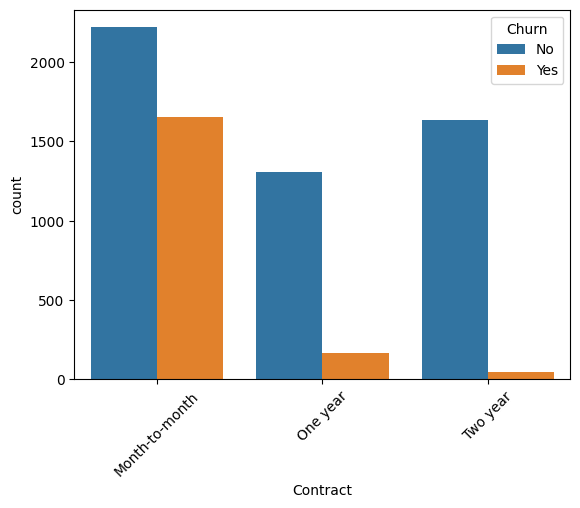

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

The countplot shows a clear relationship between the type of contract and customer churn. Customers with 'Month-to-month' contracts have a significantly higher churn rate compared to those with 'One year' or 'Two year' contracts. Conversely, customers with 'Two year' contracts show the lowest churn rates, followed by 'One year' contracts, indicating that longer-term contracts are associated with lower customer churn.

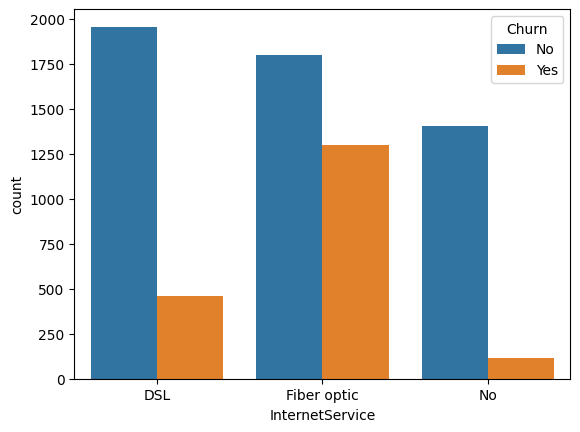

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

The countplot examining 'InternetService' and 'Churn' reveals significant differences in churn rates based on the type of internet service. Customers with 'Fiber optic' internet service show a substantially higher churn rate compared to those with 'DSL' service or no internet service at all. Conversely, customers who do not have internet service ('No') exhibit a very low churn rate, suggesting that the presence and type of internet service play a crucial role in customer retention.

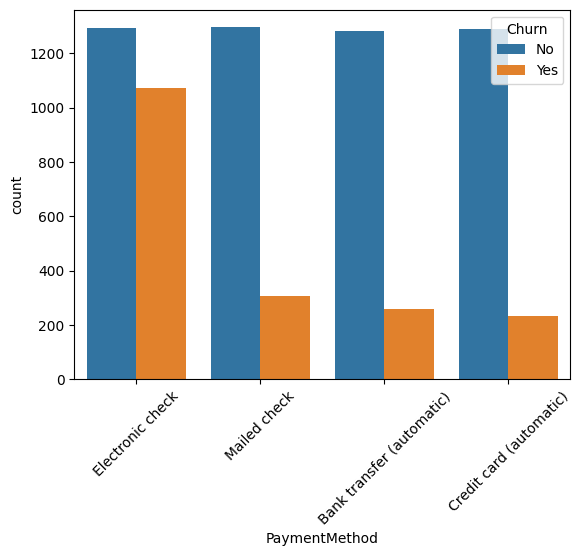

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)

plt.show()

The countplot examining 'PaymentMethod' and 'Churn' shows varying churn rates across different payment methods. Customers using 'Electronic check' appear to have the highest churn rate, significantly higher than other payment methods. Conversely, 'Credit card (automatic)' and 'Bank transfer (automatic)' show lower churn rates, suggesting that automatic payment methods are associated with greater customer retention compared to manual methods like 'Mailed check' and especially 'Electronic check'.

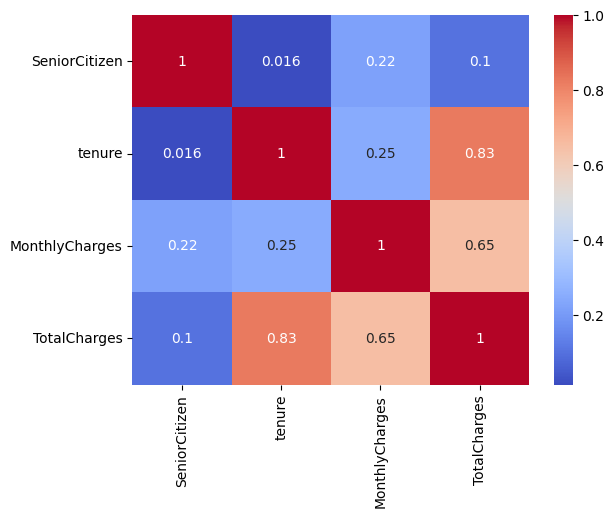

In [ ]:
import numpy as np

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

The heatmap shows the correlation between the numerical variables. We can observe a strong positive correlation between tenure and TotalCharges, which is expected as customers with longer tenure would accumulate higher total charges. There is also a notable positive correlation between MonthlyCharges and TotalCharges. The SeniorCitizen column shows very weak correlations with the other numerical features.

## 🛠️ Feature Engineering

- Converted target variable to binary  
- Applied one-hot encoding for categorical variables  
- Scaled numerical features  
- Created tenure groups to capture customer lifecycle behavior  

In [ ]:
catergorical_columns.remove('customerID')
for col in catergorical_columns:
  print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges : [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn : ['No' 'Yes']
SeniorCitizen : [0 1]


In [ ]:
# Handle Binary Columns

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


binary_col = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
              'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies',

            ]

for col in binary_col:
  df[col] = df[col].map({'Yes':1, 'No': 0 })


In [ ]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,DSL,1,0,1,1,1,1,One year,1,Mailed check,84.80,1990.50,0
7039,0,0,1,1,72,1,1,Fiber optic,0,1,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,0
7040,0,0,1,1,11,0,0,DSL,1,0,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,1,1,1,0,4,1,1,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,1


In [ ]:
# Handle Multi-Class Categorical Features by using One-Hot Encoding

df = pd.get_dummies(df, columns = ['InternetService',
    'Contract',
    'PaymentMethod'], drop_first= True)


In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,False,False,True,False,False,False,True
7039,0,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,True,False,True,False,True,False,False
7040,0,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,False,False,False,False,False,True,False
7041,1,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,True,False,False,False,False,False,True


In [ ]:
# From the tenure feature, we observe that it is a continuous variable, which can make it challenging for the model to learn and interpret effectively. This might require further discretization or transformation
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr']
)

df = pd.get_dummies(df, columns=['tenure_group'], drop_first=True)

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,0,1,0,1,0,0,0,1,0,...,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,34,1,0,1,0,1,...,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,2,1,0,1,1,0,...,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,45,0,0,1,0,1,...,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,2,1,0,0,0,0,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,False,False,True,False,False,False,True,True,False,False
7039,0,0,1,1,72,1,1,0,1,1,...,True,False,True,False,True,False,False,False,False,True
7040,0,0,1,1,11,0,0,1,0,0,...,False,False,False,False,False,True,False,False,False,False
7041,1,1,1,0,4,1,1,0,0,0,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  Streaming

## ✂️ Train-Test Split

In [ ]:
# X ->  Independent Features , y -> Dependent Features ( Target)
X = df.drop('Churn', axis = 1)
y = df['Churn']

In [ ]:
# dividing train and test data set ( applying 80:20 rule )
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## ⚖️ Feature Scaling

In [ ]:
# scaling the X_train and X_test because linear models are very sensitive
# to scale which may leads to fast convergence
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train  = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

## 🤖 Model Building (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter= 1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 📈 Model Evaluation

- Evaluated using Accuracy, Precision, Recall, F1-score  
- Observed that recall for churn class was low initially  

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249
[[931 102]
 [197 177]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



The model achieves around 78% accuracy, but recall for churn class is low (~47%), meaning it fails to identify many customers who will churn. Since churn prediction is critical, improving recall is necessary.

## 🔥 Threshold Tuning

To improve recall for churn prediction, different thresholds were tested.

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred_temp))

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      

We evaluated the logistic regression model using different classification thresholds (0.5, 0.4, 0.3, 0.2) to improve performance for churn prediction.

At the default threshold (0.5), the model achieves good overall accuracy (~79%), but recall for the churn class is low (47%), meaning many churn customers are missed.
Reducing the threshold to 0.4 improves recall to 64%, indicating the model is able to identify more churn customers, with a slight drop in precision.
At threshold 0.3, recall significantly improves to 75%, meaning the model successfully captures most churn customers. Although precision decreases, this trade-off is acceptable for churn prediction, where missing a customer is more costly than a false alarm.
Further lowering the threshold to 0.2 increases recall to 85%, but precision drops considerably (45%), leading to too many false positives and reduced overall accuracy.

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
y_pred_new = (y_prob > 0.3).astype(int)

In [ ]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[769 264]
 [ 93 281]]
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



## 🎯 Conclusion

- Logistic Regression achieved ~78% accuracy  
- Initial model had low recall for churn class  
- Threshold tuning improved recall from 47% → 75%  
- Threshold = 0.3 provided the best balance  

### 💼 Business Impact:
- Improved ability to identify at-risk customers  
- Enables proactive retention strategies  

## 🔮 Future Improvements

- Try advanced models (Random Forest, XGBoost)  
- Use SMOTE for imbalance handling  
- Perform hyperparameter tuning  
- Deploy model using Flask/Streamlit  